
# Assignment 2: Phân loại bệnh nhân có nguy cơ tiểu đường

**Model sử dụng:** Logistic Regression  
**Dataset:** Pima Indians Diabetes Dataset  
**Mục tiêu:** Dự đoán bệnh nhân có nguy cơ tiểu đường hay không.

Bài toán này là **Binary Classification**:

- `Outcome = 0`: không có nguy cơ tiểu đường
- `Outcome = 1`: có nguy cơ tiểu đường

> Lưu ý: file này không tự tải dataset. Bạn cần đặt file dataset `.csv` cùng thư mục với notebook này.



## 1. Import thư viện

Ta dùng:

- `pandas`, `numpy`: xử lý dữ liệu
- `matplotlib`, `seaborn`: trực quan hóa dữ liệu
- `sklearn`: chia dữ liệu, huấn luyện model, đánh giá model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

import warnings
warnings.filterwarnings('ignore')


## 2. Đọc dataset từ file CSV

Bạn cần đổi tên file bên dưới cho đúng với file bạn đã tải về.

Ví dụ tên file thường gặp:

```text
pima-indians-diabetes.csv
diabetes.csv
```

Nếu dataset của bạn **đã có tên cột**, dùng `pd.read_csv(file_path)`.  
Nếu dataset của bạn **chưa có tên cột**, dùng danh sách `columns` bên dưới.


In [3]:
# Đổi tên file này theo đúng file CSV bạn đã tải về
file_path = "../data/diabetes/diabetes.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# Thử đọc dataset có header trước
try:
    df = pd.read_csv(file_path)
    
    # Nếu file không có header, pandas có thể đọc dòng đầu thành tên cột dạng số
    # Khi đó ta đọc lại với names=columns
    if len(df.columns) != 9 or "Outcome" not in df.columns:
        df = pd.read_csv(file_path, names=columns)
except FileNotFoundError:
    print(f"Không tìm thấy file: {file_path}")
    print("Hãy đặt file CSV cùng thư mục với notebook hoặc sửa lại file_path.")

# Xem 5 dòng đầu
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  



## 3. Kiểm tra tổng quan dữ liệu

Ở bước này ta kiểm tra:

- số dòng, số cột
- kiểu dữ liệu
- dữ liệu bị thiếu
- thống kê cơ bản


In [4]:
print("Shape:", df.shape)
print("Thông tin dữ liệu:")
print(df.info())

print("Số giá trị thiếu trong từng cột:")
print(df.isnull().sum())

print("Thống kê mô tả:")
print(df.describe())

Shape: (768, 9)
Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Số giá trị thiếu trong từng cột:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI              


## 4. Ý nghĩa các cột trong dataset

| Cột | Ý nghĩa |
|---|---|
| Pregnancies | Số lần mang thai |
| Glucose | Nồng độ glucose trong máu |
| BloodPressure | Huyết áp |
| SkinThickness | Độ dày da |
| Insulin | Chỉ số insulin |
| BMI | Chỉ số khối cơ thể |
| DiabetesPedigreeFunction | Chỉ số di truyền liên quan đến tiểu đường |
| Age | Tuổi |
| Outcome | Kết quả: 0 là không tiểu đường, 1 là có tiểu đường |



## 5. Kiểm tra phân bố nhãn `Outcome`

Ta cần xem dataset có bị lệch nhãn không.  
Nếu số lượng `0` nhiều hơn `1` quá nhiều, model có thể bị thiên lệch.


Outcome
0    500
1    268
Name: count, dtype: int64
Tỷ lệ phần trăm:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


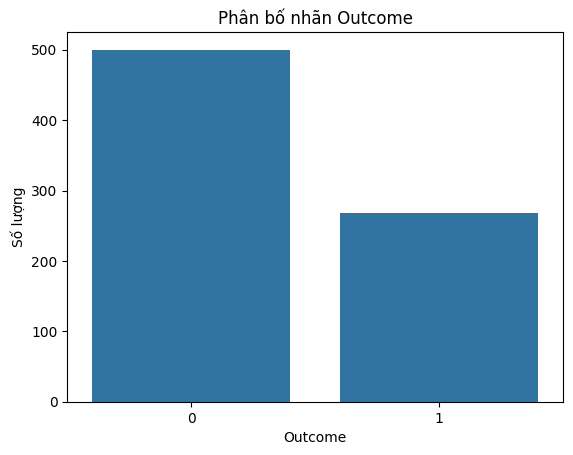

In [5]:
print(df["Outcome"].value_counts())
print("Tỷ lệ phần trăm:")
print(df["Outcome"].value_counts(normalize=True) * 100)

sns.countplot(data=df, x="Outcome")
plt.title("Phân bố nhãn Outcome")
plt.xlabel("Outcome")
plt.ylabel("Số lượng")
plt.show()


## 6. Kiểm tra các giá trị 0 bất hợp lý

Trong dataset này, một số cột không nên có giá trị bằng 0, ví dụ:

- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`

Vì người bệnh không thể có glucose hoặc huyết áp bằng 0.  
Ta sẽ xem có bao nhiêu giá trị 0 trong các cột này.


In [6]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_cols:
    print(f"{col}: {(df[col] == 0).sum()} giá trị 0")

Glucose: 5 giá trị 0
BloodPressure: 35 giá trị 0
SkinThickness: 227 giá trị 0
Insulin: 374 giá trị 0
BMI: 11 giá trị 0



## 7. Xử lý giá trị 0 bất hợp lý

Ta thay các giá trị 0 ở các cột trên bằng `NaN`, sau đó điền bằng **median** của từng cột.

Lý do dùng median:

- ít bị ảnh hưởng bởi outlier
- phù hợp hơn mean khi dữ liệu y tế có giá trị bất thường


In [8]:
df_clean = df.copy()

for col in zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Số giá trị thiếu sau xử lý:")
print(df_clean.isnull().sum())

print("Kiểm tra lại số giá trị 0:")
for col in zero_cols:
    print(f"{col}: {(df_clean[col] == 0).sum()} giá trị 0")

Số giá trị thiếu sau xử lý:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Kiểm tra lại số giá trị 0:
Glucose: 0 giá trị 0
BloodPressure: 0 giá trị 0
SkinThickness: 0 giá trị 0
Insulin: 0 giá trị 0
BMI: 0 giá trị 0



## 8. Trực quan hóa dữ liệu

Ta vẽ histogram để xem phân bố của các biến đầu vào.


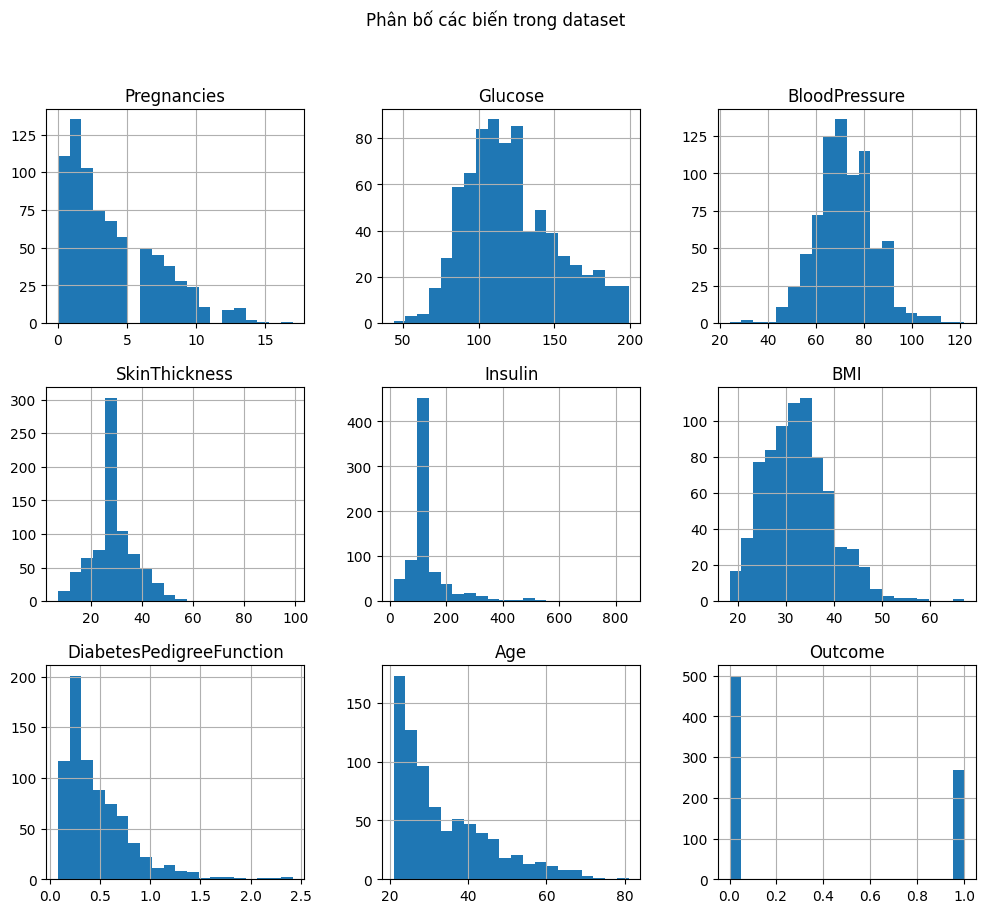

In [9]:
df_clean.hist(figsize=(12, 10), bins=20)
plt.suptitle("Phân bố các biến trong dataset")
plt.show()


## 9. Ma trận tương quan

Correlation matrix giúp xem biến nào liên quan mạnh hơn đến `Outcome`.

Giá trị gần `1`: tương quan dương mạnh  
Giá trị gần `-1`: tương quan âm mạnh  
Giá trị gần `0`: ít tương quan tuyến tính


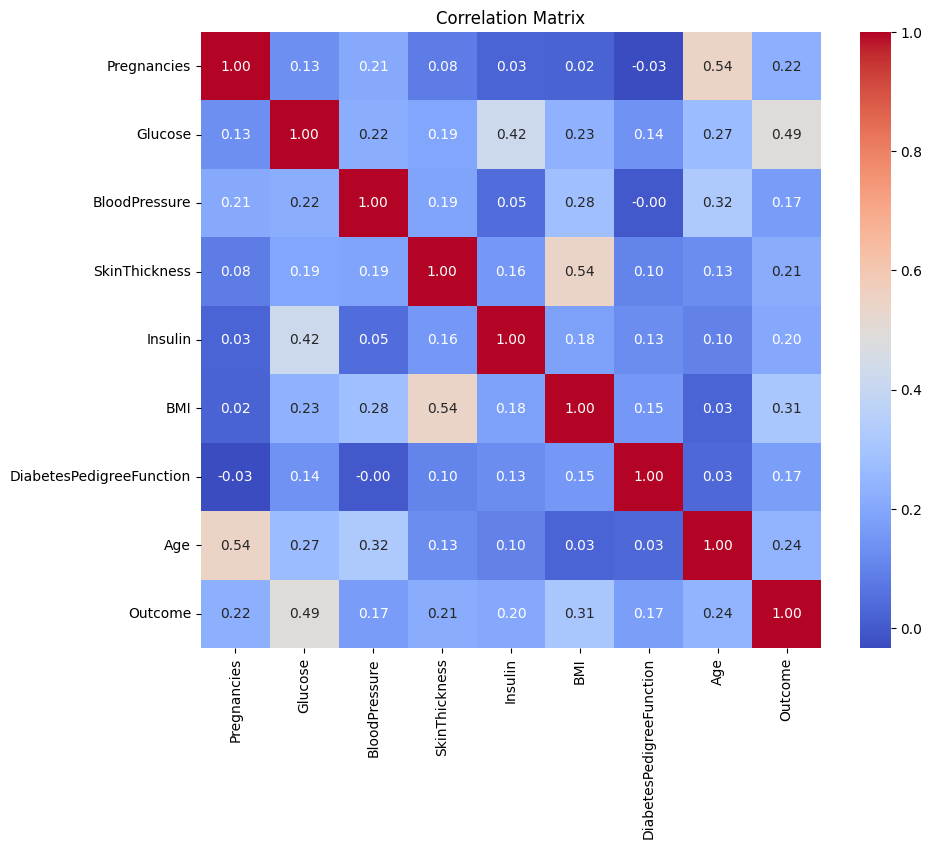

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


## 10. Tách biến đầu vào `X` và nhãn `y`

- `X`: các feature dùng để dự đoán
- `y`: kết quả cần dự đoán


In [11]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)



## 11. Chia Train/Test

Ta chia dữ liệu thành:

- 80% để train model
- 20% để test model

Dùng `stratify=y` để giữ tỷ lệ `0` và `1` tương đối giống nhau giữa train và test.


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)



## 12. Feature Scaling

Logistic Regression hoạt động tốt hơn khi các feature có cùng thang đo.

Ví dụ:

- `Age` có thể từ 20 đến 80
- `Insulin` có thể rất lớn
- `DiabetesPedigreeFunction` thường nhỏ hơn 2

Vì vậy ta dùng `StandardScaler` để chuẩn hóa dữ liệu.


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 13. Train Logistic Regression

Logistic Regression dự đoán xác suất bệnh nhân thuộc class `1`.

Công thức sigmoid:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Trong đó:

$$
z = w_1x_1 + w_2x_2 + ... + w_nx_n + b
$$

Nếu xác suất lớn hơn 0.5, model thường dự đoán là `1`.


In [14]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Train xong Logistic Regression model.")

Train xong Logistic Regression model.



## 14. Dự đoán trên tập test


In [15]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("5 dự đoán đầu tiên:", y_pred[:5])
print("5 xác suất đầu tiên:", y_pred_proba[:5])

5 dự đoán đầu tiên: [1 0 0 0 0]
5 xác suất đầu tiên: [0.60971073 0.11835576 0.29346313 0.2508367  0.03320667]



## 15. Đánh giá model bằng Accuracy

Accuracy là tỷ lệ dự đoán đúng trên tổng số mẫu.

$$
Accuracy = \frac{Số\ dự\ đoán\ đúng}{Tổng\ số\ dự\ đoán}
$$


In [16]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.7078



## 16. Confusion Matrix

Confusion Matrix cho biết model dự đoán đúng/sai như thế nào.

|  | Predict 0 | Predict 1 |
|---|---|---|
| Actual 0 | True Negative | False Positive |
| Actual 1 | False Negative | True Positive |

Trong bài toán y tế, **False Negative** khá nguy hiểm vì bệnh nhân có nguy cơ nhưng model lại dự đoán là không có nguy cơ.


[[82 18]
 [27 27]]


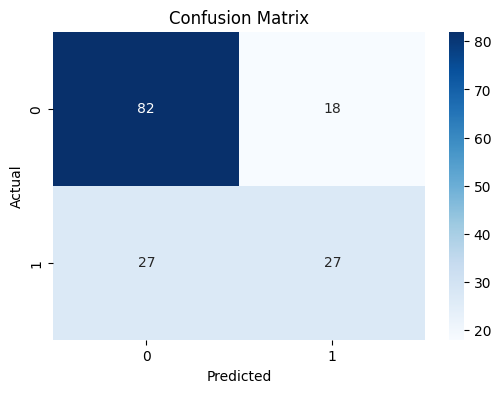

In [17]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 17. Classification Report

Các chỉ số quan trọng:

- **Precision:** trong các bệnh nhân model dự đoán là có nguy cơ, có bao nhiêu người thật sự có nguy cơ
- **Recall:** trong các bệnh nhân thật sự có nguy cơ, model phát hiện được bao nhiêu người
- **F1-score:** trung bình điều hòa giữa precision và recall

Với bài toán bệnh lý, ta nên chú ý nhiều đến **Recall của class 1**.


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154




## 18. ROC Curve và AUC

ROC Curve thể hiện khả năng phân biệt giữa class `0` và class `1`.

AUC càng gần `1` càng tốt.  
AUC khoảng `0.5` nghĩa là model gần như đoán ngẫu nhiên.


AUC: 0.813


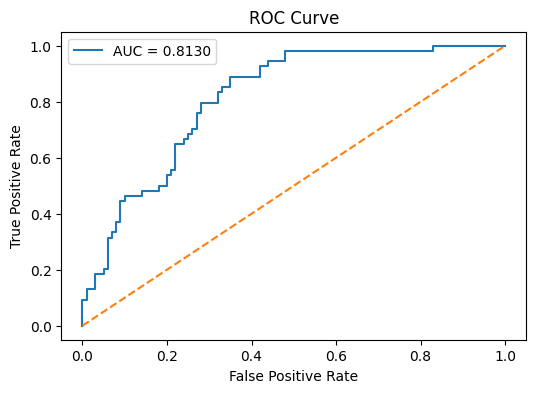

In [19]:
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", round(auc, 4))

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## 19. Xem hệ số của model

Hệ số giúp ta hiểu feature nào ảnh hưởng đến dự đoán của Logistic Regression.

- hệ số dương: feature tăng thì xác suất class `1` tăng
- hệ số âm: feature tăng thì xác suất class `1` giảm


                    Feature  Coefficient  Abs_Coefficient
1                   Glucose     1.182511         1.182511
5                       BMI     0.688735         0.688735
0               Pregnancies     0.377502         0.377502
6  DiabetesPedigreeFunction     0.233386         0.233386
7                       Age     0.147798         0.147798
4                   Insulin    -0.066157         0.066157
2             BloodPressure    -0.044066         0.044066
3             SkinThickness     0.028225         0.028225


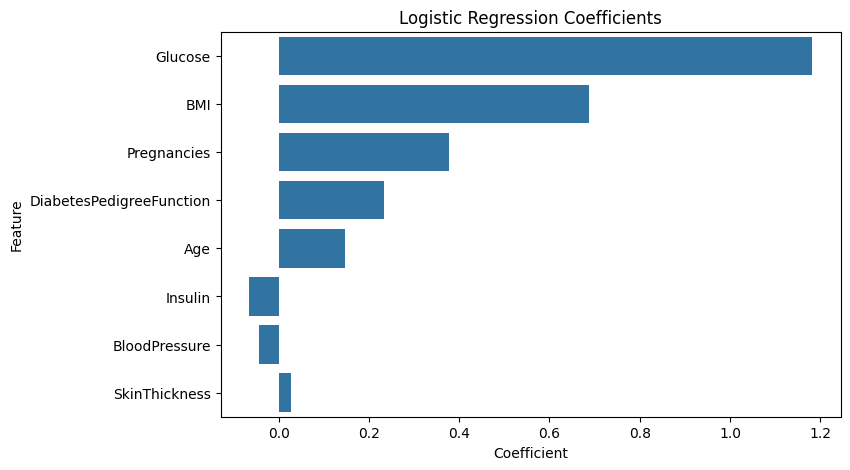

In [20]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

print(coef_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x="Coefficient", y="Feature")
plt.title("Logistic Regression Coefficients")
plt.show()


## 20. Dự đoán thử một bệnh nhân mới

Ví dụ bệnh nhân mới có thông tin:

| Feature | Giá trị |
|---|---:|
| Pregnancies | 2 |
| Glucose | 120 |
| BloodPressure | 70 |
| SkinThickness | 20 |
| Insulin | 79 |
| BMI | 25.0 |
| DiabetesPedigreeFunction | 0.5 |
| Age | 33 |


In [28]:
new_patient = pd.DataFrame([[2, 150, 140, 20, 79, 24.0, 1, 50]], columns=X.columns)

new_patient_scaled = scaler.transform(new_patient)

new_prediction = model.predict(new_patient_scaled)
new_probability = model.predict_proba(new_patient_scaled)[:, 1]

print("Prediction:", new_prediction[0])
print("Probability of diabetes risk:", round(new_probability[0], 4))

if new_prediction[0] == 1:
    print("Kết luận: bệnh nhân được dự đoán CÓ nguy cơ tiểu đường.")
else:
    print("Kết luận: bệnh nhân được dự đoán KHÔNG có nguy cơ tiểu đường.")

Prediction: 0
Probability of diabetes risk: 0.3867
Kết luận: bệnh nhân được dự đoán KHÔNG có nguy cơ tiểu đường.



## 21. Thử thay đổi threshold

Mặc định Logistic Regression thường dùng threshold = 0.5.

Nhưng trong bài toán y tế, ta có thể giảm threshold xuống 0.4 hoặc 0.3 để phát hiện nhiều ca nguy cơ hơn.

Đổi lại, model có thể báo động nhầm nhiều hơn.


Classification Report với threshold = 0.4
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       100
           1       0.61      0.65      0.63        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.73      0.74       154



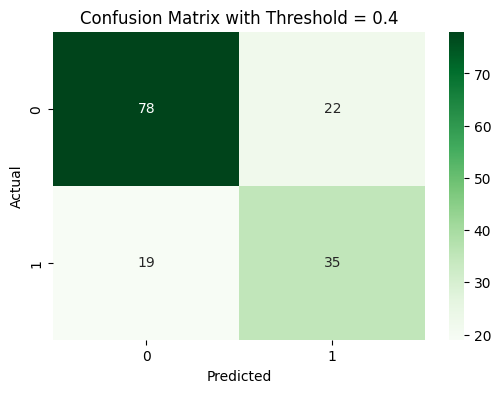

In [24]:
threshold = 0.4

y_pred_threshold = (y_pred_proba >= threshold).astype(int)

print("Classification Report với threshold =", threshold)
print(classification_report(y_test, y_pred_threshold))

cm_threshold = confusion_matrix(y_test, y_pred_threshold)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_threshold, annot=True, fmt="d", cmap="Greens")
plt.title(f"Confusion Matrix with Threshold = {threshold}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 22. Kết luận

Trong mini project này, ta đã thực hiện đầy đủ pipeline Machine Learning:

1. Đọc dataset Pima Indians Diabetes
2. Kiểm tra và làm sạch dữ liệu
3. Xử lý các giá trị 0 bất hợp lý
4. Chia train/test
5. Chuẩn hóa feature bằng `StandardScaler`
6. Huấn luyện Logistic Regression
7. Đánh giá bằng Accuracy, Confusion Matrix, Classification Report và AUC
8. Dự đoán bệnh nhân mới
9. Thử thay đổi threshold để quan sát kết quả

**Nhận xét:** Logistic Regression là model đơn giản, dễ giải thích và phù hợp để bắt đầu với bài toán phân loại nguy cơ tiểu đường. Tuy nhiên, trong bài toán y tế, không nên chỉ nhìn Accuracy. Cần chú ý thêm Recall của class `1`, vì bỏ sót bệnh nhân có nguy cơ là vấn đề nghiêm trọng hơn.
